# Smart Irrigation Prediction Using Machine Learning

## Objective
Analyze environmental and agricultural data to understand patterns behind irrigation needs.


## Goals
- Identify key variables affecting irrigation
- Explore relationships between features
- Generate actionable insights

## Dataset Source

This dataset is extracted from Kaggle

In [14]:
import pandas as pd

# Load dataset
df = pd.read_csv('../data/raw/train.csv')

In [15]:
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [17]:
df.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


## Correlation Analysis

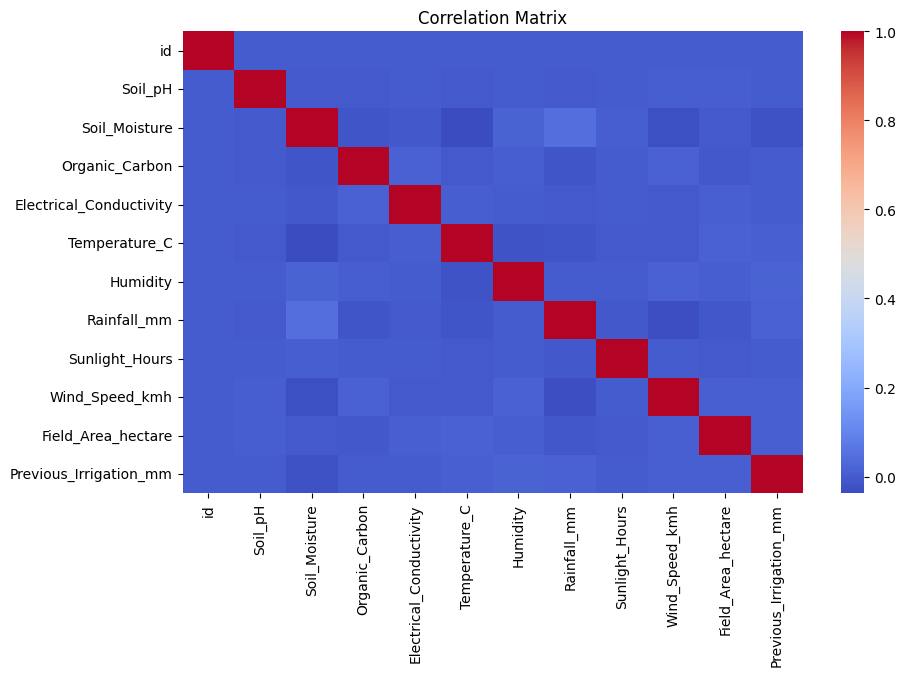

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [19]:
df.shape

(630000, 21)

In [20]:
df.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

## Data Overview
- The dataset contains 630,000 records and 21 features
- There are no missing values across any column
- The dataset includes:
    - 11 numerical variables
    - 9 categorical variables
- Memory usage is ~100 MB, indicating a large-scale dataset
- This dataset includes environmental and agricultural variables that influence irrigation decisions, such as soil conditions, weather, and crop characteristics.

## Data Cleaning

- The dataset was inspected for missing values and inconsistencies.

    - No missing values were found
    - Data types were appropriate for analysis
    - No immediate data cleaning was required

## Feature Description

- The dataset contains:

    - Environmental variables (Temperature, Humidity, Rainfall)
    - Soil characteristics (Soil Type, Soil Moisture, pH)
    - Agricultural factors (Crop Type, Growth Stage)
    - Operational variables (Irrigation Type, Water Source)

- These features are expected to influence irrigation demand.

In [21]:
df['Irrigation_Need'].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

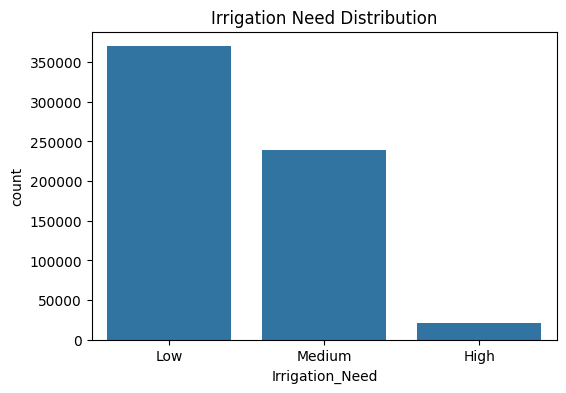

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Irrigation_Need')
plt.title("Irrigation Need Distribution")
plt.show()

## Target Distribution Insight

-   The dataset shows a clear class imbalance:
    - The majority of observations fall into the "Low" irrigation category
    - "Medium" represents a significant portion
    - "High" irrigation demand is underrepresented

- This imbalance could affect model performance, as models may become biased toward predicting the majority class.

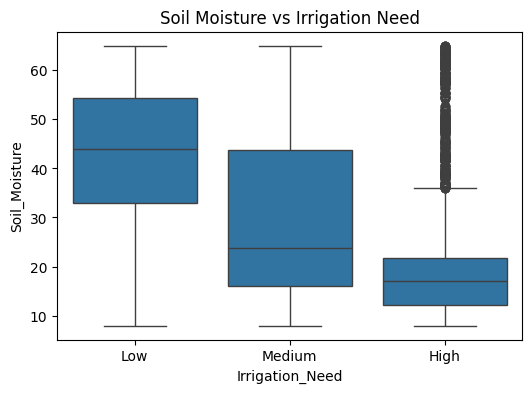

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Irrigation_Need', y='Soil_Moisture')
plt.title("Soil Moisture vs Irrigation Need")
plt.show()

## Soil Moisture vs Irrigation Need

- A clear inverse relationship is observed between soil moisture and irrigation demand:
    - Low irrigation need is associated with higher soil moisture levels
    - Medium irrigation shows moderate moisture levels
    - High irrigation demand occurs when soil moisture is low

- This indicates that soil moisture is one of the strongest predictors of irrigation requirements.
- Outliers in the "High" irrigation category suggest that additional variables such as temperature, crop type, or evaporation may influence irrigation needs beyond soil moisture alone.

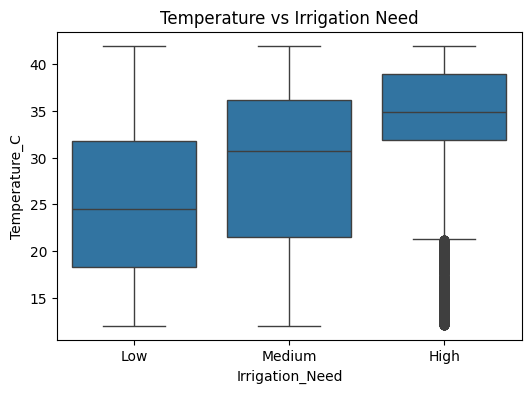

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Irrigation_Need', y='Temperature_C')
plt.title("Temperature vs Irrigation Need")
plt.show()

## Temperature vs Irrigation Need

- A clear positive relationship is observed between temperature and irrigation demand:

    - Higher temperatures are associated with increased irrigation needs
    - The "High" irrigation category shows the highest median temperatures
    - The "Low" category corresponds to lower temperature ranges

- This suggests that temperature plays a significant role in driving water demand, likely due to increased evaporation.
- Lower temperature outliers in the "High" irrigation category suggest that other variables (such as soil type or crop type) also influence irrigation demand.

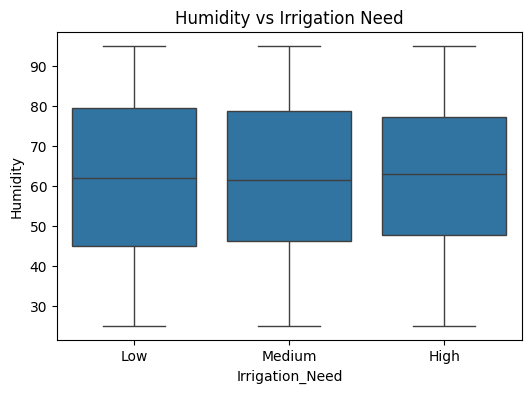

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Irrigation_Need', y='Humidity')
plt.title("Humidity vs Irrigation Need")
plt.show()

## Humidity vs Irrigation Need

-  Unlike other variables, humidity does not show a strong relationship with irrigation demand:

    - The distributions across all categories are very similar
    - Median humidity values are nearly identical for Low, Medium, and High irrigation
    - There is significant overlap between all groups

- This suggests that humidity alone is not a strong predictor of irrigation needs and may need to be analyzed in combination with other variables.

# Final Insights

- Soil moisture is the strongest predictor of irrigation needs
- Temperature has a positive relationship with irrigation demand
- Humidity does not show a strong individual impact
- The dataset is imbalanced, with fewer high irrigation cases

## Business Insight

- Efficient irrigation strategies should prioritize soil moisture and temperature monitoring rather than relying solely on humidity levels.

- Understanding irrigation drivers can help:
    - Optimize water usage
    - Reduce costs in agricultural operations
    - Improve crop yield efficiency
    - Enable smarter irrigation system

## Modeling Preparation

Based on the exploratory analysis, we proceed to build a predictive model using environmental and agricultural variables.

# Modeling
## Objective
Build a machine learning model to predict irrigation needs based on environmental and agricultural variables.

## Considerations
- The dataset is imbalanced (few "High" cases)
- Evaluation metrics beyond accuracy are important
- To validate model robustness, we remove potentially leakage-prone features such as previous irrigation.

In [26]:
# Imports
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd

# Drop columns
cols_to_drop = ['Previous_Irrigation_mm']
df_model = df.drop(cols_to_drop + ['id'], axis=1)

# Encoding
df_encoded = df_model.copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Features / target
X = df_encoded.drop('Irrigation_Need', axis=1)
y = df_encoded['Irrigation_Need']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# ROC AUC
y_prob = rf.predict_proba(X_test)
auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

print(f"ROC AUC Score: {auc:.4f}")

              precision    recall  f1-score   support

           0       0.97      0.90      0.93      4249
           1       0.99      1.00      0.99     73737
           2       0.98      0.98      0.98     48014

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000

[[ 3812     0   437]
 [    0 73414   323]
 [   99   996 46919]]
ROC AUC Score: 0.9955


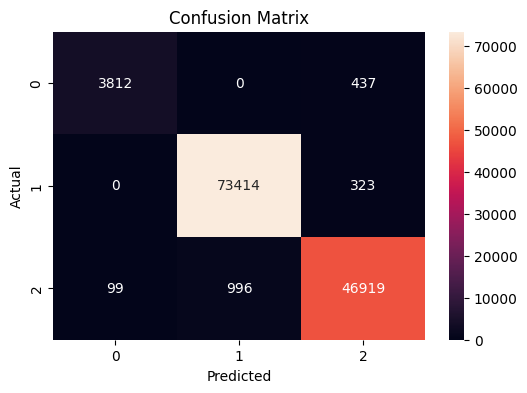

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Evaluation

- The model achieved very high performance across all classes:

    - Overall accuracy is approximately 99%
    - Precision and recall are consistently high
    - The model performs well even on the minority class ("High")

- The confusion matrix shows that most predictions are correct, with only minor misclassifications between neighboring classes.

## Interpretation

- The strong performance suggests that the dataset contains clear patterns that allow the model to effectively distinguish between irrigation levels.

- Even after removing potentially leakage-prone features, the model maintained high performance, indicating robust predictive relationships.

## Feature Importance

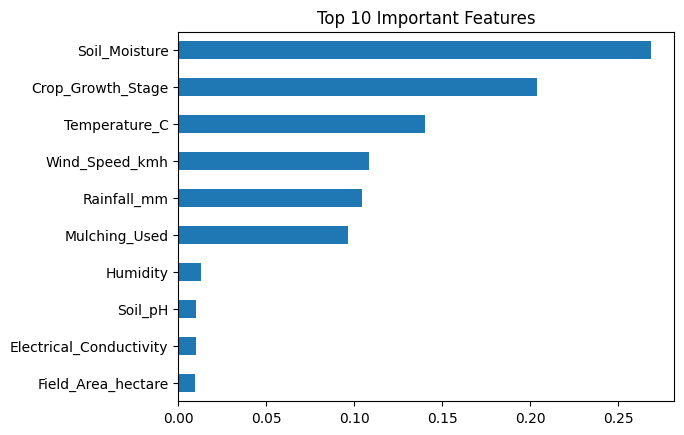

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

## Feature Importance Analysis

- The model identifies the following features as the most influential:

    - Soil Moisture (by far the most important predictor)
    - Crop Growth Stage
    - Temperature

- Soil moisture stands out as the dominant factor, confirming the strong inverse relationship observed during exploratory analysis.

- Crop growth stage also plays a significant role, indicating that irrigation needs depend not only on environmental conditions but also on the development stage of the crop.

- Temperature further contributes to irrigation demand, likely due to its effect on evaporation rates.

- This alignment between EDA findings and model results increases confidence in the model's reliability.

- Additionally, the presence of crop-related variables among the top features suggests that irrigation strategies should consider both environmental and biological factors.

## Limitations

- Class imbalance may affect prediction of the "High" irrigation class
- Some features may be highly correlated
- Label encoding may not fully capture categorical relationships

# Final Conclusion

This project demonstrates that irrigation needs can be accurately predicted using environmental and agricultural data.

Soil moisture, crop growth stage, and temperature were identified as the most important drivers of irrigation demand.

These insights can help optimize irrigation strategies, reduce water usage, and improve agricultural efficiency.